# Multiple Linear Regression


In this project, a Multiple Linear Regression model was developed to analyze how different features influence the target variable and to make predictions based on these relationships. The dataset was preprocessed by handling categorical variables and scaling numerical features to improve model performance. The goal of the analysis is to understand underlying patterns in the data and evaluate how effectively the model can generalize to unseen data while maintaining reliable prediction accuracy.

In [1]:
# Importing libraries for analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

#Importing the dataset
insurance=pd.read_csv('insurance.csv',sep=',')

Saving insurance.csv to insurance.csv


# Dataset overview and basic statistics

In [3]:
insurance.head()
#first 5 rows

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.shape
#shape of dataset (rows,columns)

(1338, 7)

This dataset contains 7 columns and 1338 rows.

In [5]:
insurance.info()
#the columns and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


All data types are correct, we don't need to change any of them.

In [6]:
insurance.duplicated().sum()
#checking duplicate rows

np.int64(1)

We found that there is 1 duplicated row. Since duplicate data can affect the analysis and model performance, we will now remove this duplicated row from the dataset.

In [7]:
insurance.drop_duplicates(inplace=True)
#removing duplicate rows

After removing the duplicate row, the dataset is now clean and contains only unique records. This ensures better data quality and helps improve the reliability of the model.

In [8]:
insurance.isnull().sum()
#do we have null values or not

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


We don't have null values, so we don't need to drop or fill any columns.

In [9]:
insurance.dtypes
#rechecking data types

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Check the data types of each column and identify numerical and categorical features.

## Exploratory Data Analysis (EDA)

In [10]:
#numerical and categorical column lists
numerical_cols=insurance.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols=insurance.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


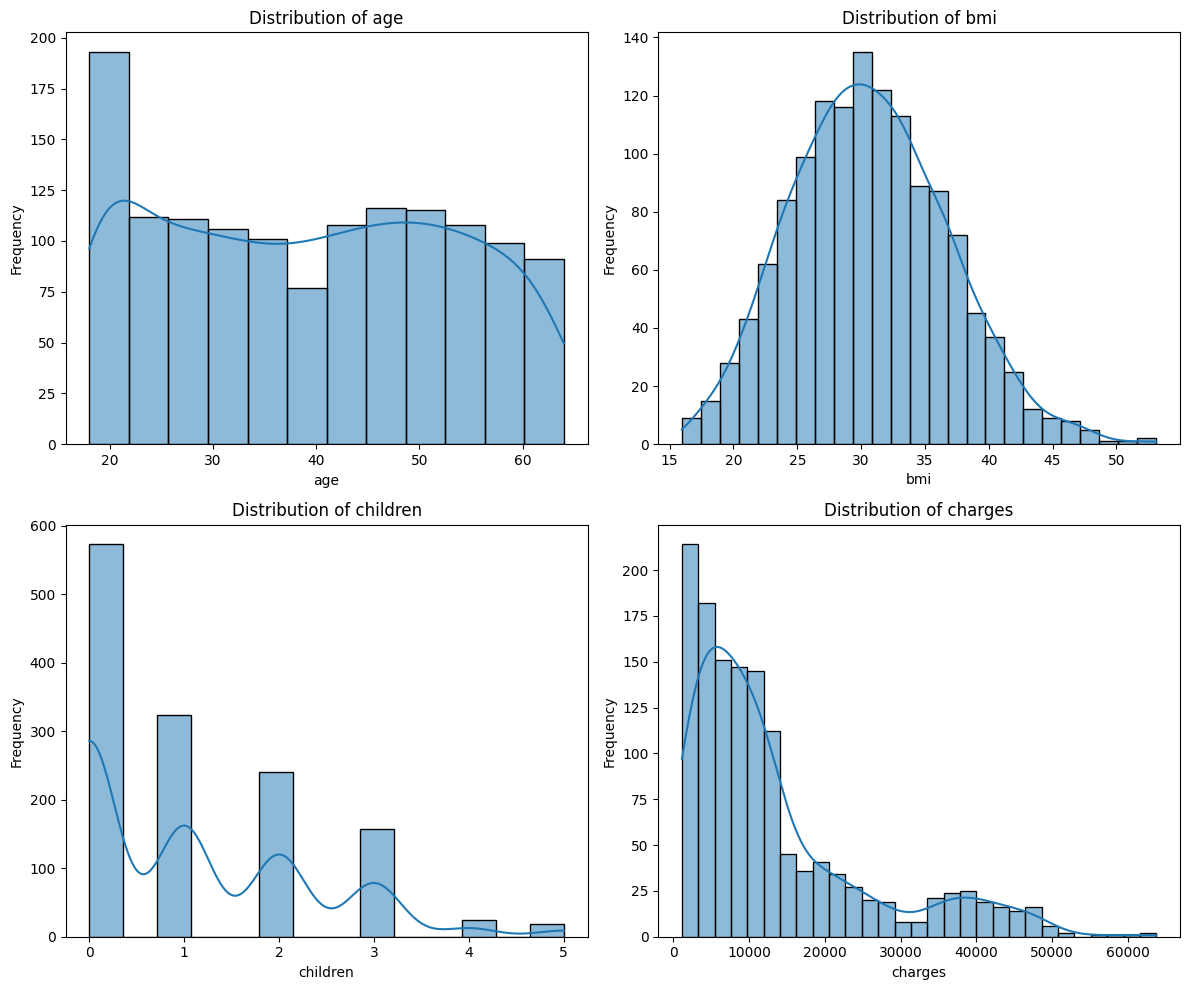

In [11]:
#check whether data follows a normal distribution and identify skewness and outliers
numerical_cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(insurance[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Age is fairly uniformly distributed and does not follow a normal distribution, BMI is approximately normally distributed, children is discrete and right-skewed, and charges is highly right-skewed with many outliers and deviates strongly from normality.

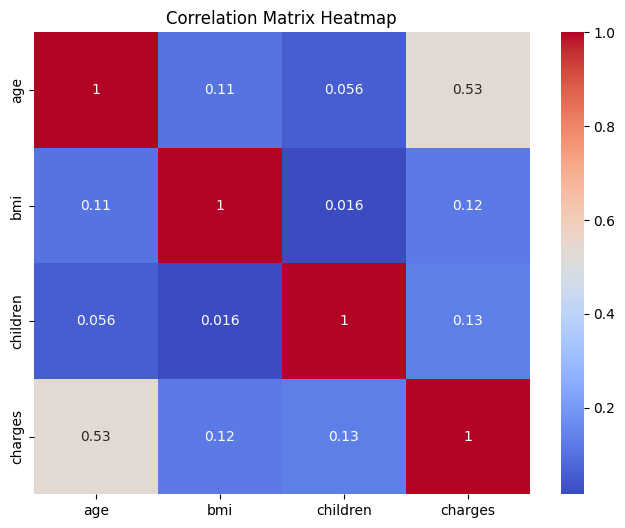

In [12]:
#relationships between numerical variables using Spearman Correlation
corr_matrix = insurance[numerical_cols].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

We used Spearman correlation because it measures monotonic relationships (increasing or decreasing trends) and does not assume that the data is normally distributed.

Age and BMI have a very weak positive correlation, age and children also show an extremely weak positive correlation, and BMI and children are almost uncorrelated, indicating that there are no strong linear relationships among these variables.

In [13]:
#finding high correlation
features = ['age', 'bmi', 'children']
corr_features = insurance[features].corr(method='spearman')
high_corr_pairs = []
for i in range(len(corr_features.columns)):
    for j in range(i):
        corr_value = corr_features.iloc[i, j]
        if abs(corr_value) > 0.85:
            col1 = corr_features.columns[i]
            col2 = corr_features.columns[j]
            high_corr_pairs.append((col1, col2, corr_value))
print("High correlation pairs:", high_corr_pairs)

High correlation pairs: []


There are no feature pairs with high correlation, meaning none of the variables are strongly related to each other in a monotonic way.

## Linear Model Training

In [14]:
from sklearn.model_selection import train_test_split

#splitting Data into Training and Testing Sets
X = insurance.drop('charges', axis=1)
y = insurance[["charges"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=99)

We split the dataset into training (80%) and testing (20%) sets, where the model is trained on the training data and evaluated on the test data to measure its performance.

In [15]:
#One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=['sex', 'smoker', 'region'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['sex', 'smoker', 'region'], drop_first=True)

We apply One-Hot Encoding to convert the categorical variables (sex, smoker, and region) into numerical format for both the training and test sets.

In [16]:
from sklearn.preprocessing import StandardScaler

#Standard Scaling
numerical_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

We apply StandardScaler to standardize the numerical features by fitting it on the training data and transforming both the training and test sets so that the features have zero mean and unit variance.

In [17]:
from sklearn.linear_model import LinearRegression

#Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

We create a Linear Regression model and train it using the training data to learn the relationship between the features and the target variable.

In [18]:
#predict the values
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

We use the trained Linear Regression model to predict the target variable for both the test data and the training data in order to evaluate the model’s performance on unseen and seen data.

In [19]:
X_test['charge']=y_pred
X_test['actual_values']=y_test
X_test.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charge,actual_values
156,0.625292,-1.023699,-0.903209,True,True,False,True,False,31107.568436,21223.6758
123,0.341334,0.119237,-0.079378,True,True,False,False,False,34143.717671,39556.4945
1269,0.412324,-0.515728,1.568284,True,False,False,False,True,9380.597279,8615.3000
512,0.838261,-1.353551,-0.903209,True,False,False,False,False,8268.376929,9361.3268
377,-1.078456,1.570585,-0.903209,True,True,False,True,False,30491.329188,38126.2465


The predicted values generated by the model were compared with the actual values to evaluate how accurately the model performs.

In [20]:
#intercept
model.intercept_

array([9092.84682761])

The intercept (bias term) of the linear regression model indicates that when all input features are equal to 0, the model’s baseline predicted value is approximately 9092.85.

In [21]:
#coefficients
model.coef_

array([[ 3678.37546503,  2178.16779326,   643.02689428,  -378.8586012 ,
        23965.49753907,  -301.33317185, -1061.40035228,  -735.1800062 ]])

The coefficients of the linear regression model show how much each feature influences the target variable.

Based on the obtained coefficients, smoker status have a very strong positive impact on charges, while other variables such as age, BMI, and children also increase charges to a lesser extent and some features like region indicators slightly decrease the predicted value.

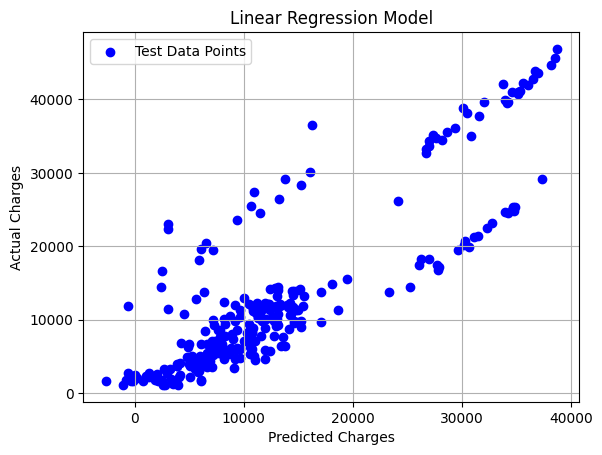

In [22]:
plt.scatter(y_pred, y_test, color='blue', label='Test Data Points')
plt.title('Linear Regression Model')
plt.xlabel('Predicted Charges')
plt.ylabel('Actual Charges')
plt.legend()
plt.grid(True)
plt.show()

Overall, the model captures the trend correctly, meaning there is a reasonable alignment between the predicted and actual values. However, the noticeable scatter of points indicates that there is still some error in the model, and it is not perfectly accurate.

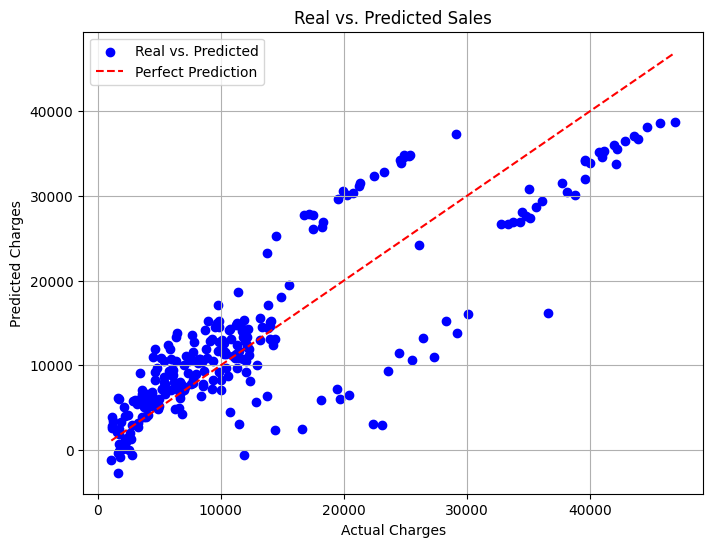

In [23]:
real_values = X_test['actual_values'].tolist()
predicted_values = X_test['charge'].tolist()
plt.figure(figsize=(8, 6))
plt.scatter(real_values, predicted_values, color='blue', label='Real vs. Predicted')
plt.plot([min(real_values), max(real_values)], [min(real_values), max(real_values)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Real vs. Predicted Sales')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.grid(True)
plt.show()

Although the model makes accurate predictions in some cases, overall many points are far from the ideal line, especially at higher values where the model fails to predict correctly, indicating that its accuracy is moderate and needs improvement.

## Model Evaluation

MSE (Mean Squared Error): Measures the average of squared differences between actual and predicted values. It penalizes large errors more heavily.

RMSE (Root Mean Squared Error): The square root of MSE. It expresses the error in the same units as the target variable, making it easier to interpret.

MAE (Mean Absolute Error): Represents the average absolute difference between actual and predicted values. It shows how far predictions are from the real values on average.

MAPE (Mean Absolute Percentage Error): Expresses the error as a percentage. A small adjustment is made using np.where to avoid division by zero when actual values are 0.

R² Score: Indicates how well the model explains the variance in the data. A value closer to 1 means a better-fitting model.

### Model evaluation in train dataset

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Evaluation of Regression Model Using Error Metrics
actual_values=y_train
predicted_values=y_pred_train
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, predicted_values)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
r_squared = r2_score(actual_values, predicted_values)
print("R-squared:", r_squared)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

R-squared: 0.754412857919166
Mean Absolute Percentage Error (MAPE): 42.42848662350132 %
Mean Squared Error: 37052777.24038968
Root Mean Squared Error: 6087.099246799717
Mean Absolute Error: 4183.92227280289


The model explains about 75% of the variance in the data, which indicates a reasonably good ability to capture the overall trend. However, the error metrics show that the predictions are not very precise, as the MAPE is quite high at 42%, meaning the model makes relatively large percentage errors on average. In addition, the RMSE and MAE suggest that the model’s predictions deviate noticeably from the actual values. Overall, while the model captures the general pattern of the data, its prediction accuracy is still limited.

### Model  evaluation in  test  dataset

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Evaluation of Regression Model Using Error Metrics
actual_values=y_test
predicted_values=y_pred
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, predicted_values)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
r_squared = r2_score(actual_values, predicted_values)
print("R-squared:", r_squared)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

R-squared: 0.7317858749256239
Mean Absolute Percentage Error (MAPE): 44.11688636968385 %
Mean Squared Error: 34679697.136562355
Root Mean Squared Error: 5888.947031224033
Mean Absolute Error: 4295.957672702157


The model explains about 73% of the variance in the data, which shows that it still captures the general trend reasonably well. However, the error metrics indicate that the predictions are not highly accurate, as the MAPE is quite high at around 44%, meaning the model makes relatively large percentage errors on average. Additionally, the RMSE and MAE show that there is a noticeable difference between the predicted and actual values. Overall, the model performs similarly on both training and test data, suggesting consistent but only moderate predictive accuracy.

# Conclusion

The model shows similar performance on both the training and test datasets, which indicates that it is not overfitting and is able to learn general patterns from the data rather than memorizing it. The R² values suggest that the model explains a reasonable portion of the variance in the target variable, indicating moderate to good performance. However, the relatively high values of MAPE, RMSE, and MAE show that there is still a significant difference between the predicted and actual values. Overall, the model is stable and generalizes well.